In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from tabulate import tabulate
from astropy.time import Time
from tqdm import tqdm
#from scipy.spatial.distance import pdist, squareforme
import numpy as np
from astropy.time import Time
import datetime
from collections import defaultdict
from scipy.spatial import cKDTree
import os
import glob
from collections import Counter
import matplotlib.ticker as ticker



In [7]:
#loading in VLA coherent and incoherent files
df_coh = pd.read_pickle('/datax/scratch/ellambishop/test_refine/non_vlass_other.pkl')
df_incoh = pd.read_pickle('/datax/scratch/ellambishop/test_refine/non_vlass_incoherent.pkl')

columns = ['file_uri', 'observation_id','source_name', 'beam_id', 'ra_hours', 'dec_degrees', 'tstart',
               'signal_frequency', 'signal_beam', 'signal_drift_rate', 'signal_snr',
               'signal_power', 'signal_incoherent_power', 'signal_num_timesteps']
              # 'incoh_power', 'incoh_snr', 'freq_has_incoherent_counterpart', 'freq_has_phase_center_counterpart' ]
coh_df= df_coh[columns]
incoh_df = df_incoh[columns]

print(len(coh_df), len(incoh_df))

1942776 1342625


In [ ]:

freq_tol = 1e-6        
drift_tol = 1e-3   

# Ensure neat indexing
coh_df = coh_df.reset_index(drop=True)
incoh_df = incoh_df.reset_index(drop=True)

coh_coords = np.vstack([
    coh_df["signal_frequency"].values / freq_tol,
    coh_df["signal_drift_rate"].values / drift_tol
]).T

incoh_coords = np.vstack([
    incoh_df["signal_frequency"].values / freq_tol,
    incoh_df["signal_drift_rate"].values / drift_tol
]).T

tree = cKDTree(coh_coords)

# Query nearest coherent candidate for each incoherent entry (distance in scaled space)
dists, idxs = tree.query(incoh_coords, distance_upper_bound=1.0)

# Gather all potential matches within tolerance, with their true distances in original units if wanted
potential_matches = []
for incoh_idx, (dist_scaled, coh_idx) in enumerate(zip(dists, idxs)):
    if coh_idx == len(coh_df) or np.isinf(dist_scaled):
        continue
    freq_diff = abs(incoh_df.loc[incoh_idx, "signal_frequency"] - coh_df.loc[coh_idx, "signal_frequency"])
    drift_diff = abs(incoh_df.loc[incoh_idx, "signal_drift_rate"] - coh_df.loc[coh_idx, "signal_drift_rate"])

    potential_matches.append({
        "scaled_dist": dist_scaled,
        "coh_idx": int(coh_idx),
        "incoh_idx": int(incoh_idx),
        "freq_diff": float(freq_diff),
        "drift_diff": float(drift_diff),
        "snr_coh": float(coh_df.loc[coh_idx, "signal_snr"]) if "signal_snr" in coh_df.columns else np.nan,
        "snr_incoh": float(incoh_df.loc[incoh_idx, "signal_snr"]) if "signal_snr" in incoh_df.columns else np.nan
    })

# Sort by scaled distance (closest first). Optional secondary sort: prefer higher SNR.
potential_matches.sort(key=lambda x: (x["scaled_dist"], -x["snr_incoh"], -x["snr_coh"]))

used_coh = set()
used_incoh = set()
matched_pairs = []

for pm in potential_matches:
    coh_idx = pm["coh_idx"]
    incoh_idx = pm["incoh_idx"]
    if coh_idx in used_coh or incoh_idx in used_incoh:
        continue
    coh_row = coh_df.iloc[coh_idx]
    incoh_row = incoh_df.iloc[incoh_idx]

    pair = {
        'observation_id': coh_row.get('observation_id'),
        "ra_hours": coh_row.get('ra_hours'),
        "dec_degrees": coh_row.get('dec_degrees'),
        "file_uri": coh_row.get("file_uri"),
        "incoh_file": incoh_row.get("file_uri"),
        "signal_frequency": coh_row["signal_frequency"],
        "signal_beam": coh_row.get('signal_beam'),
        "signal_power": coh_row["signal_power"],
        "incoh_power": incoh_row["signal_power"],
        "power_ratio": coh_row["signal_power"] / incoh_row["signal_power"] if incoh_row["signal_power"] > 0 else np.nan,
        "tstart": coh_row.get("tstart"),
        "tstart_incoh": incoh_row.get("tstart"),
        "beam_id": coh_row.get("beam_id"),
        "beam_incoh": incoh_row.get("beam_id"),
        'signal_snr': coh_row.get('signal_snr'),
        'snr_incoh': incoh_row.get('signal_snr'),
        'signal_drift_rate': coh_row.get('signal_drift_rate'),
        'drift_incoh': incoh_row.get('signal_drift_rate'),
        'freq_diff': pm["freq_diff"],
        'drift_diff': pm["drift_diff"],
        'scaled_dist': pm["scaled_dist"]
    }

    matched_pairs.append(pair)
    used_coh.add(coh_idx)
    used_incoh.add(incoh_idx)

matched_df = pd.DataFrame(matched_pairs)
matched_df['signal_frequency'] = matched_df['signal_frequency'].round(6)

# Unmatched sets for diagnostics
unmatched_coh = coh_df.drop(index=list(used_coh))
unmatched_incoh = incoh_df.drop(index=list(used_incoh))

# Stats
print("Coherent hits total:", len(coh_df))
print("Matched coherent hits:", len(used_coh))
print("Unmatched coherent hits:", len(unmatched_coh))
print("Incoherent hits total:", len(incoh_df))
print("Matched incoherent hits:", len(used_incoh))
print("Unmatched incoherent hits:", len(unmatched_incoh))

full_df = matched_df


Coherent hits total: 1942776
Matched coherent hits: 344525
Unmatched coherent hits: 1598251
Incoherent hits total: 1342625
Matched incoherent hits: 344525
Unmatched incoherent hits: 998100


In [10]:
#compute power ratio with paired incoherent values

plt.hist(matched_df['power_ratio'], bins=50)
plt.yscale('log')
plt.axvline(3, color='r', linestyle='--')
plt.axvline(5, color='r', linestyle='--')
plt.xlabel('Coherent / Incoherent Power Ratio')
plt.ylabel('Count')
plt.title('Power Ratio Distribution')
plt.close()


In [11]:
#visualizing differences between coherent and incoherent hits 
no_incoh_df = unmatched_coh
has_incoh_df = matched_df

features = ['signal_frequency', 'signal_snr', 'signal_power', 'signal_drift_rate']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    # Plot KDEs on each subplot
    sns.kdeplot(no_incoh_df[col].dropna(), label='No Incoherent', fill=True, ax=axes[i])
    sns.kdeplot(has_incoh_df[col].dropna(), label='Has Incoherent', fill=True, ax=axes[i])
    
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True)
    
    if col == 'signal_snr':
        axes[i].set_xlim(7, 11)
    elif col == 'signal_power':
        axes[i].set_xscale('log')
        axes[i].set_xlim(1e11, 1e15)
        axes[i].set_yscale('log')
    elif col == 'signal_drift_rate':
        axes[i].set_xlim(-10, 10)

# plt.tight_layout()
plt.close()

In [44]:
gaia_df= pd.read_pickle('/datax/scratch/ellambishop/meerkat_hits/meerkat_gaia.pkl')
#gaia_df= pd.read_pickle('/datax/scratch/ellambishop/meerkat_hits/meerkat_named.pkl')

def add_meerkat_config(df):
    df = df.copy() 
    df.loc[df['signal_frequency'] < 2000, 'config'] = 'MeerKAT'
    return df

add_meerkat_config(gaia_df)

,file_uri,source_name,beam_id,ra_hours,dec_degrees,tstart,signal_frequency,signal_beam,signal_drift_rate,signal_snr,signal_power,signal_incoherent_power,signal_num_timesteps,filterbank_tsamp,observation_id,is_gaia,config
0,None,Gaia_2775987485397299072,1,11.081799,12.616624,60578.955519,849.996627,1,0.211866,47.681538,9.900518e+15,0.0,36,7.89516,guppi_60578_82556_000102_J0042+1246_0001.hits,True,MeerKAT
1,None,Gaia_2776209724185243392,2,10.300795,12.886880,60578.955519,849.996627,2,0.211866,47.771255,9.938714e+15,0.0,36,7.89516,guppi_60578_82556_000102_J0042+1246_0001.hits,True,MeerKAT
2,None,Gaia_2775979685736671360,3,10.997184,12.477080,60578.955519,849.996627,3,0.211866,46.755730,9.741742e+15,0.0,36,7.89516,guppi_60578_82556_000102_J0042+1246_0001.hits,True,MeerKAT
3,None,Gaia_2775605508186063616,4,10.769034,12.378236,60578.955519,849.996626,4,0.215940,48.050922,1.003262e+16,0.0,36,7.89516,guppi_60578_82556_000102_J0042+1246_0001.hits,True,MeerKAT
4,None,Gaia_2776212301165618944,5,10.364884,12.992893,60578.955519,849.996627,5,0.211866,48.233017,1.000716e+16,0.0,36,7.89516,guppi_60578_82556_000102_J0042+1246_0001.hits,True,MeerKAT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48790,None,Gaia_2776010918738853376,59,10.877367,12.876508,60579.001989,839.974391,59,-0.067227,6.352823,2.126854e+15,0.0,36,7.89516,guppi_60579_00171_000118_J0042+1246_0001.hits,True,MeerKAT
48791,None,Gaia_2776198003218736640,60,10.687386,12.876648,60579.001989,839.974391,60,-0.067227,6.801643,2.199170e+15,0.0,36,7.89516,guppi_60579_00171_000118_J0042+1246_0001.hits,True,MeerKAT
48792,None,Gaia_2776188932247812224,61,10.530836,12.698939,60579.001989,839.974391,61,-0.067227,6.601429,2.161555e+15,0.0,36,7.89516,guppi_60579_00171_000118_J0042+1246_0001.hits,True,MeerKAT
48793,None,Gaia_2776213808698585472,62,10.349707,13.040919,60579.001989,839.974391,62,-0.065189,7.025441,2.235861e+15,0.0,36,7.89516,guppi_60579_00171_000118_J0042+1246_0001.hits,True,MeerKAT


In [5]:
#    Adds VLA configuration (config), date, and number of antennas to a dataframe based on tstart (MJD).
   # Expects df to contain a column 'tstart' in MJD format.
def add_vla_config(df):
 

    # --- Extended VLA configuration date ranges ---
    vla_config_ranges = [
        (datetime.date(2023, 1, 19), datetime.date(2023, 5, 29), 'B'),
        (datetime.date(2023, 6, 2),  datetime.date(2023, 6, 19), 'BnA'),
        (datetime.date(2023, 6, 30), datetime.date(2023, 10, 2), 'A'),
        (datetime.date(2023, 10, 3), datetime.date(2023, 10, 19), 'A'),
        (datetime.date(2023, 10, 20), datetime.date(2024, 1, 15), 'D'),
        (datetime.date(2024, 1, 16), datetime.date(2024, 1, 24), 'D'),   # patch
        (datetime.date(2024, 1, 25), datetime.date(2024, 5, 7), 'C'),
        (datetime.date(2024, 5, 8),  datetime.date(2024, 9, 16), 'B'),
        (datetime.date(2024, 9, 17), datetime.date(2024, 10, 7), 'BnA'),
        (datetime.date(2024, 10, 8), datetime.date(2025, 2, 3), 'A'),
        (datetime.date(2025, 2, 4), datetime.date(2025, 2, 24), 'A'),     # new patch
        (datetime.date(2025, 2, 25), datetime.date(2025, 5, 12), 'D'),
        (datetime.date(2025, 5, 13), datetime.date(2025, 5, 21), 'C'),    # patch
        (datetime.date(2025, 5, 22), datetime.date(2025, 8, 18), 'C'),
        (datetime.date(2025, 8, 19), datetime.date(2025, 9, 2), 'B'),     # patch
        (datetime.date(2025, 9, 3),  datetime.date(2026, 1, 20), 'B'),
    ]


    # Config → number of antennas (nominal value = 27)
    config_to_n_antennas = {
        'A': 27,
        'B': 27,
        'C': 27,
        'D': 27,
        'BnA': 27,
        'CnB': 27,
        'Unknown': np.nan
    }

    # Initialize new columns
    dates, configs, n_antennas_list = [], [], []

    for t in df['tstart']:
        try:
            time = Time(t, format='mjd')
            date_str = time.to_value('iso', subfmt='date')
            date_obj = datetime.datetime.strptime(date_str, "%Y-%m-%d").date()
            dates.append(date_str)

            matched_config = 'Unknown'
            for start, end, cfg in vla_config_ranges:
                if start <= date_obj <= end:
                    matched_config = cfg
                    break
            configs.append(matched_config)
            n_antennas_list.append(config_to_n_antennas.get(matched_config, np.nan))

        except Exception as e:
            print(f"[!] Error parsing tstart={t}: {e}")
            dates.append('Invalid')
            configs.append('Unknown')
            n_antennas_list.append(np.nan)

    # Update dataframe
    df = df.copy()
    df['date'] = dates
    df['config'] = configs
    df['n_antennas'] = n_antennas_list

    return df

full_df = add_vla_config(full_df)
print(full_df['config'].value_counts())
print(full_df[['config', 'n_antennas']].drop_duplicates())

unmatched_coh = add_vla_config(unmatched_coh)
print(unmatched_coh['config'].value_counts())
print(unmatched_coh[['config', 'n_antennas']].drop_duplicates())


config
D      171401
A      114164
B       46291
C       11861
BnA       808
Name: count, dtype: int64
     config  n_antennas
0         A          27
1         D          27
13        B          27
66        C          27
1390    BnA          27
config
D      685364
A      631344
B      206966
C       64758
BnA      9819
Name: count, dtype: int64
       config  n_antennas
1           D          27
59795       C          27
181460      A          27
248018      B          27
393212    BnA          27


In [150]:
# calculate and assign the size of the beam for each hit 
def assign_beam_size_arcsec(df):
    import numpy as np

    # Beam size per band and configuration (arcsec)
    beam_resolutions = {
        'P' : {'MeerKAT': 13},
        'L':  {'MeerKAT': 13}, 
        'S':  {'D': 23, 'C': 7.0, 'B': 2.1, 'A': 0.65},
        'C':  {'D': 12, 'C': 3.5, 'B': 1.0, 'A': 0.33},
        'X':  {'D': 7.2, 'C': 2.1, 'B': 0.6, 'A': 0.20},
    }

    # Frequency bands in MHz
    conditions = [
        (df['signal_frequency'] >= 0)   & (df['signal_frequency'] < 850),
        (df['signal_frequency'] >= 850)  & (df['signal_frequency'] < 1800),
        (df['signal_frequency'] >= 2000) & (df['signal_frequency'] < 4000),
        (df['signal_frequency'] >= 4000) & (df['signal_frequency'] < 8000),
        (df['signal_frequency'] >= 8000) & (df['signal_frequency'] < 12000),
    ]
    band_labels = ['P', 'L', 'S', 'C', 'X']
    
    df = df.copy()
    # Assign band
    df['band'] = np.select(conditions, band_labels, default='Unknown')

    # Default config if not present
    if 'config' not in df.columns:
        df['config'] = 'MeerKAT'

    # Create lookup dictionary
    beam_lookup = {
        (band, cfg): size
        for band, cfgs in beam_resolutions.items()
        for cfg, size in cfgs.items()
    }

    df['beam_key'] = list(zip(df['band'], df['config']))
    df['beam_size_arcsec'] = df['beam_key'].map(beam_lookup)

    return df

#VLA hits 
full_df= assign_beam_size_arcsec(full_df)
unmatched_coh = assign_beam_size_arcsec(unmatched_coh)

#MeerKAT hits
gaia_df = assign_beam_size_arcsec(gaia_df)

In [187]:
def flag_local_rfi(df, field, area_multiplier=3,
                   beam_threshold_fraction=0.75, drift_tol=1.0, beam_col='signal_beam',
                    frequency_tol=1.0, freq_col='signal_frequency', min_beams_floor =3):
    
    from scipy.spatial import ConvexHull

    """ Vectorized form of flag overlapping signals that have the same file URI/FOV but are in 
    spacially separated beams as potential RFI """

    df = df.copy()
    df['freq_bin'] = (df[freq_col] / frequency_tol).round().astype(int)
    df['drift_bin'] = (df['signal_drift_rate'] / drift_tol).round().astype(int)
    df['rfi_flag_local'] = False
    df['drift_bin'] = (df['signal_drift_rate'] / drift_tol).round().astype(int)
    local_flag_count = 0

    beam_count_by_fov = df.groupby(field)['signal_beam'].nunique().to_dict()
    dec_mean_by_fov = df.groupby(field)['dec_degrees'].mean().to_dict()

    for fov, fov_group in df.groupby(field):
        total_beams = beam_count_by_fov.get(fov, 0)
        min_required_beams = max(3, int(beam_threshold_fraction * total_beams))
        dec0 = dec_mean_by_fov[fov]
        cos_dec = np.cos(np.deg2rad(dec0))
        avg_beam_size = fov_group['beam_size_arcsec'].mean()
        beam_area = np.pi * (avg_beam_size / 2) ** 2
        threshold_area = area_multiplier * beam_area

        for (freq, drift_bin), combo in fov_group.groupby(
                ['signal_frequency', 'drift_bin']):
            if combo['signal_beam'].nunique() < min_required_beams or len(combo) < 3:
                continue

            ra0 = combo['ra_hours'].mean()
            ra_off = (combo['ra_hours'] - ra0) * 3600 * cos_dec
            dec_off = (combo['dec_degrees'] - dec0) * 3600
            points = np.vstack([ra_off, dec_off]).T

            try:
                hull = ConvexHull(points)
                hit_area = hull.area
            except Exception:
                hit_area = 0

            if hit_area > threshold_area:
                df.loc[combo.index, 'rfi_flag_local'] = True
                local_flag_count += len(combo)

    return df, local_flag_count

In [188]:
def flag_temporal_persistence_rfi_fast(
    df,
    frequency_tol=1.0,       
    drift_tol=1.0,            
    radius_arcsec=None,       
    radius_multiplier=3,      
    min_time_gap_sec=10,      
    min_repeat_count=2,   
):
    """
    Vectorized replacement for flag_temporal_persistence_rfi.
 
    Flags signals whose (freq_bin, drift_bin) appears at the same sky position
    across multiple observations separated by at least min_time_gap_sec seconds.

    """
    
    df = df.copy()
    df["rfi_flag_global"] = False
 
    # ---- binning ----
    df["freq_bin"] = (df["signal_frequency"] / frequency_tol).round().astype(int)
    df["drift_bin"] = (df["signal_drift_rate"] / drift_tol).round().astype(int)
 
    # ---- sky coords in arcsec (flat-sky approximation, good for small FOV) ----
    dec_mean = df["dec_degrees"].mean()
    df["_ra_arcsec"] = df["ra_hours"] * 3600.0 * np.cos(np.deg2rad(dec_mean))
    df["_dec_arcsec"] = df["dec_degrees"] * 3600.0
 
    # ---- tstart in seconds ----
    df["_tstart_sec"] = df["tstart"] * 86400.0  # MJD days → seconds
 
    # ---- per-row radius ----
    if radius_arcsec is not None:
        df["_radius"] = float(radius_arcsec)
    else:
        df["_radius"] = radius_multiplier * df["beam_size_arcsec"].fillna(13.0)
 
    flagged_indices = set()
 
    grouped = df.groupby(["freq_bin", "drift_bin"])
 
    for (fb, db), grp in grouped:
        if len(grp) < min_repeat_count:
            continue
 
        ra = grp["_ra_arcsec"].values
        dec = grp["_dec_arcsec"].values
        t = grp["_tstart_sec"].values
        r = grp["_radius"].values
        idx = grp.index.values  # original DataFrame indices
 
        n = len(grp)
 
        # pairwise distances and time gaps — O(N²) but N is small per group
        ra_diff = ra[:, None] - ra[None, :]       # (n, n)
        dec_diff = dec[:, None] - dec[None, :]
        dist = np.sqrt(ra_diff**2 + dec_diff**2)
 
        t_diff = np.abs(t[:, None] - t[None, :])  # seconds
 
        # radius threshold: use the larger of the two radii in each pair
        r_thresh = np.maximum(r[:, None], r[None, :])
 
        # valid neighbour: spatially close AND temporally separated
        valid = (dist <= r_thresh) & (t_diff >= min_time_gap_sec)
        np.fill_diagonal(valid, False)
 
        # count valid neighbours per row
        repeat_counts = valid.sum(axis=1)
 
        flag_mask = repeat_counts >= (min_repeat_count - 1)
        if flag_mask.any():
            flagged_indices.update(idx[flag_mask].tolist())
 
    df.loc[list(flagged_indices), "rfi_flag_global"] = True
 
    # clean up helper columns
    df = df.drop(columns=["_ra_arcsec", "_dec_arcsec", "_tstart_sec", "_radius"],
                 errors="ignore")
 
    return df, len(flagged_indices)

In [189]:

def flag_global_freq_repeats(df, freq_col='signal_frequency', drift_col='signal_drift_rate', 
                              time_col='tstart', obs_col = 'observation_id', flag_col='rfi_flag_global'):
    
    """ 
    Flags frequency–drift combinations that appear across multiple observations (FOVs),
    identifying globally recurring signals that are likely persistent interference or RFI.
    """
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        print("[!] Skipping: DataFrame is None or empty.")
        return df

    if 'flag_strength' not in df.columns:
        df['flag_strength'] = 0

    repeat_groups = df.groupby([freq_col, drift_col])[obs_col].nunique()
    suspect_freqs = repeat_groups[repeat_groups > 1].index

    df['global_freq_repeat'] = df.set_index([freq_col, drift_col]).index.isin(suspect_freqs)

    # Sets flag and increments strength only for newly caught signals
    df.loc[df['global_freq_repeat'], flag_col] = True
    df.loc[df['global_freq_repeat'], 'flag_strength'] += 1

    print(f"Temporal persistence global RFI flagged: {df[flag_col].sum()}")
    print(f"Multi-FOV freq+drift repeats flagged: {df['global_freq_repeat'].sum()}")

    return df

In [190]:
def add_beam_count_flag(df, field):
    """
    Adds how many beams each signal frequency appears in per FOV,
    and a categorical beam_group column replacing the old df splits.
    """
    beam_counts = (
        df.groupby([field, 'signal_frequency'])['signal_beam']
        .nunique()
        .rename('n_beams_detected')
        .reset_index()
    )
    df = df.merge(beam_counts, on=[field, 'signal_frequency'], how='left')
    
    df['beam_group'] = pd.cut(
        df['n_beams_detected'],
        bins=[0, 2, 5, np.inf],
        labels=['1-2 beams', '3-5 beams', '6+ beams']
    )
    return df

def safe_mjd_to_datetime(mjd_series, min_mjd=40000, max_mjd=80000):
    # Coerce non-numeric values to NaN
    mjd_series = pd.to_numeric(mjd_series, errors='coerce')
    
    # Only keep plausible MJDs
    valid_mask = (mjd_series >= min_mjd) & (mjd_series <= max_mjd)
    
    out = pd.Series(pd.NaT, index=mjd_series.index)
    if valid_mask.any():
        out.loc[valid_mask] = Time(mjd_series.loc[valid_mask], format='mjd').to_datetime()
    return out

In [201]:
INSTRUMENT_CONFIGS = {
    'vla': {
        'field': 'file_uri',
        'beam_threshold_fraction': 0.5,
        'min_beams_floor': 2,
        'min_time_gap_sec': 600,
        'min_unique_tstarts': 20,
        'frequency_tol': 0.001,  # 1 kHz — comfortably above 5 Hz resolution
        'drift_tol': 1.0,
        'min_repeat_count': 3

    },
    'meerkat': {
        'field': 'observation_id',
        'beam_threshold_fraction': 0.5,
        'min_beams_floor': 2,
        'min_time_gap_sec': 0.3,   
        'min_unique_tstarts': 5,
        'frequency_tol': 0.001,  # same 1 kHz window as VLA
        'drift_tol': 1.0,
        'min_repeat_count' : 2
    },
}

def call_func(df, title, instrument='vla'):
    if not isinstance(df, pd.DataFrame) or df.empty:
        print(f"{title} is missing or empty; skipping.")
        return 0, 0, df

    print(f"Processing {title} ({len(df):,} hits)...")

    cfg = INSTRUMENT_CONFIGS[instrument]
    field = cfg['field']
    print(f"[i] Instrument: {instrument.upper()} | field: {field}")

    df['tstart_datetime'] = safe_mjd_to_datetime(df['tstart'])
    df['rfi_flag_global'] = False
    df['rfi_flag_local']  = False
    df['flag_strength']   = 0

    # Stage 1: local
    df, local_count = flag_local_rfi(
        df, field,
        beam_threshold_fraction=cfg['beam_threshold_fraction'],
        min_beams_floor=cfg['min_beams_floor'],
    )
    df.loc[df['rfi_flag_local'], 'flag_strength'] += 1
    print(f"[1] Local flags:    {local_count}")

    # Stage 2: temporal
    n_tstarts = df['tstart'].nunique()
    if n_tstarts < cfg['min_unique_tstarts']:
        print(f"[2] Temporal skipped — only {n_tstarts} unique tstarts")
        global_count = 0
    else:
        df = df.sort_values('tstart').reset_index(drop=True)
        df, global_count = flag_temporal_persistence_rfi_fast(
            df, min_time_gap_sec=cfg['min_time_gap_sec'], 
            frequency_tol=cfg['frequency_tol'],  # is this line actually there?
            drift_tol=cfg['drift_tol'],
            min_repeat_count= cfg['min_repeat_count']
        )
        df.loc[df['rfi_flag_global'], 'flag_strength'] += 1
        print(f"[2] Temporal flags: {global_count}")

    # Stage 3: global freq repeats
    df = flag_global_freq_repeats(df,obs_col='observation_id')
    print(f"[3] Global flags:   {df['global_freq_repeat'].sum()}")

    df = add_beam_count_flag(df, field)
    print(f"\nBeam group distribution:\n{df['beam_group'].value_counts()}")
    print(f"Flag strength distribution:\n{df['flag_strength'].value_counts().sort_index()}")

    return local_count, global_count, df

In [244]:
#VLA data 
local_count, global_count, df_vla = call_func(full_df,     'VLA hits',  instrument='vla')
# ocal_count_unmatched, global_count_unmatched, df_vla_unmatched = call_func(unmatched_coh,'VLA hits unmatched',  instrument='vla')

# #MeerKAT data 
local_count_meer, global_count_meer, df_meerkat  = call_func(gaia_df, 'MeerKAT hits', instrument='meerkat')


Processing VLA hits (344,525 hits)...
[i] Instrument: VLA | field: file_uri
[1] Local flags:    39
[2] Temporal flags: 117447
Temporal persistence global RFI flagged: 117447
Multi-FOV freq+drift repeats flagged: 0
[3] Global flags:   0

Beam group distribution:
beam_group
1-2 beams    344474
3-5 beams        51
6+ beams          0
Name: count, dtype: int64
Flag strength distribution:
flag_strength
0    227045
1    117474
2         6
Name: count, dtype: int64
Processing MeerKAT hits (48,795 hits)...
[i] Instrument: MEERKAT | field: observation_id
[1] Local flags:    29615
[2] Temporal flags: 114
Temporal persistence global RFI flagged: 474
Multi-FOV freq+drift repeats flagged: 362
[3] Global flags:   362

Beam group distribution:
beam_group
6+ beams     40930
1-2 beams     4975
3-5 beams     2890
Name: count, dtype: int64
Flag strength distribution:
flag_strength
0    18881
1    29739
2      173
3        2
Name: count, dtype: int64


In [245]:
def compute_beam_occupancy(
    df,
    freq_tol=1.0,        # MHz
    drift_tol=0.5,       # Hz/s — use 1 fine-channel step as in the literature
    beam_col="beam_id",
    freq_col="signal_frequency",
    drift_col="signal_drift_rate",
    tstart_col="tstart",
    total_beams=64,      # MeerKAT has 64 simultaneous beams
):
    """
    Compute beam occupancy fraction for each unique signal group.
 
    For each (tstart, freq_bin, drift_bin) group, counts how many distinct
    beams contain that signal and divides by total_beams to get occupancy ∈ [0,1].
 
    A genuine technosignature should appear in exactly 1 beam (occupancy ≈ 1/64).
    RFI that couples into the receiver chain appears in all or most beams
    (occupancy → 1).
    """
    df = df.copy()
 
    df["_freq_bin"] = (df[freq_col] / freq_tol).round().astype(int)
    df["_drift_bin"] = (df[drift_col] / drift_tol).round().astype(int)
 
    # group per observation (tstart) so we don't conflate different obs epochs
    group_cols = [tstart_col, "_freq_bin", "_drift_bin"]
 
    beam_counts = (
        df.groupby(group_cols)[beam_col]
        .nunique()
        .reset_index()
        .rename(columns={beam_col: "n_beams_occupied"})
    )
    beam_counts["beam_occupancy"] = beam_counts["n_beams_occupied"] / total_beams
 
    # merge back onto original df
    df = df.merge(beam_counts[group_cols + ["n_beams_occupied", "beam_occupancy"]],
                  on=group_cols, how="left")
 
    df = df.drop(columns=["_freq_bin", "_drift_bin"], errors="ignore")
 
    # summary table — one row per group
    occupancy_summary = beam_counts.copy()
    occupancy_summary["beam_occupancy_pct"] = (
        occupancy_summary["beam_occupancy"] * 100
    ).round(1)
 
    return df, occupancy_summary
 
 
def label_beam_occupancy_rfi(
    df,
    single_beam_thresh=0.05,   # ≤ 5 % of beams → candidate
    rfi_thresh=0.75,            # ≥ 75 % of beams → strong RFI (matches flag_local_rfi default)
    occupancy_col="beam_occupancy",
):
    """
    Add a categorical 'occupancy_label' column based on beam occupancy fraction.
    """
    df = df.copy()
 
    if occupancy_col not in df.columns:
        raise ValueError(
            f"Column '{occupancy_col}' not found. Run compute_beam_occupancy first."
        )
 
    conditions = [
        df[occupancy_col] <= single_beam_thresh,
        df[occupancy_col] >= rfi_thresh,
    ]
    choices = ["candidate", "rfi"]
    df["occupancy_label"] = np.select(conditions, choices, default="maybe_rfi")
 
    if "flag_strength" not in df.columns:
        df["flag_strength"] = 0
 
    df.loc[df["occupancy_label"] == "maybe_rfi", "flag_strength"] += 1
    df.loc[df["occupancy_label"] == "rfi", "flag_strength"] += 2
 
    return df


def plot_beam_occupancy_distribution(df, occupancy_col="beam_occupancy",
                                     total_beams=64, save_path=None):
    """
    Plot histogram of beam occupancy fraction with reference lines.
 
    Produces a figure suitable for an RNAAS: shows the fraction of signals
    found in N beams, with vertical lines marking the single-beam threshold
    and the 75 % RFI threshold.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
    occ = df[occupancy_col].dropna()
    n_beams = (occ * total_beams).round().astype(int)
 
    # left: histogram of beam count
    ax = axes[0]
    bins = np.arange(0, total_beams + 2) - 0.5
    ax.hist(n_beams, bins=bins, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.axvline(1, color="green", linestyle="--", linewidth=1.5,
               label="Single beam (candidate)")
    ax.axvline(total_beams * 0.75, color="red", linestyle="--", linewidth=1.5,
               label="75 % threshold (RFI)")
    ax.set_xlabel("Number of beams occupied")
    ax.set_ylabel("Number of signals")
    ax.set_yscale("log")
    ax.legend(fontsize=8)
    ax.set_title("Beam multiplicity distribution")
 
    # right: cumulative fraction
    ax2 = axes[1]
    sorted_occ = np.sort(occ)
    cdf = np.arange(1, len(sorted_occ) + 1) / len(sorted_occ)
    ax2.plot(sorted_occ * total_beams, cdf, color="steelblue", linewidth=1.5)
    ax2.axvline(1, color="green", linestyle="--", linewidth=1.5,
                label=f"1 beam: {(occ <= 1/total_beams).mean()*100:.1f}% of signals")
    ax2.axvline(total_beams * 0.75, color="red", linestyle="--", linewidth=1.5,
                label=f"≥75% beams: {(occ >= 0.75).mean()*100:.1f}% of signals")
    ax2.set_xlabel("Number of beams occupied")
    ax2.set_ylabel("Cumulative fraction of signals")
    ax2.legend(fontsize=8)
    ax2.set_title("Cumulative beam occupancy")
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()
    return fig
 

In [ ]:
""" Calling analysis functions physical properties to add to flagging properties """

df_meerkat, occ_summary = compute_beam_occupancy(df_meerkat)
df_meerkat = label_beam_occupancy_rfi(df_meerkat)

df_vla, occ_summary_vla = compute_beam_occupancy(df_meerkat)
df_vla= label_beam_occupancy_rfi(df_meerkat)

df_vla_unmatched, occ_summary_vla_unmatched = compute_beam_occupancy(df_meerkat)
df_vla_unmatched = label_beam_occupancy_rfi(df_meerkat)

In [12]:

def plot_panel_1(df, total_beams=64):
    occ = df["beam_occupancy"].dropna()
    n_beams = (occ * total_beams).round().astype(int)

    fig, ax = plt.subplots(figsize=(6,4))

    bins = np.arange(0, total_beams + 2) - 0.5
    ax.hist(n_beams, bins=bins, color="steelblue", edgecolor="white", linewidth=0.5)

    ax.axvline(1, linestyle="--", color="green", label="Single-beam expectation")
    ax.axvline(total_beams * 0.75, linestyle="--", color="red", label="RFI regime")

    ax.set_yscale("log")
    ax.set_xlabel("Number of beams occupied")
    ax.set_ylabel("Count")
    ax.set_title("Beam Occupancy Distribution")
    ax.legend()

    plt.tight_layout()
    return fig

def plot_panel_2(df):
    fig, ax = plt.subplots(figsize=(6,4))

    ax.scatter(
        df["beam_occupancy"],
        df["flag_strength"],
        s=2,
        alpha=0.25
    )

    ax.set_yscale("log")
    ax.set_xlabel("Beam occupancy (fraction)")
    ax.set_ylabel("RFI flag strength")
    ax.set_title("RFI strength vs beam occupancy")

    plt.tight_layout()
    return fig

def plot_panel_3(df):
    fig, ax = plt.subplots(figsize=(6,4))

    order = ["candidate", "maybe_rfi", "rfi"]

    data = [
        df[df["occupancy_label"] == lab]["flag_strength"]
        for lab in order
    ]

    ax.boxplot(data, labels=order, showfliers=False)

    ax.set_yscale("log")
    ax.set_ylabel("RFI flag strength")
    ax.set_title("RFI strength by occupancy class")

    plt.tight_layout()
    return fig


def call_plotting(df):
    fig1 = plot_panel_1(df)
    fig2 = plot_panel_2(df)
    fig3 = plot_panel_3(df)
    return plt.show()

# call_plotting(df_meerkat)
# call_plotting(df_vla)
# call_plotting(df_vla_unmatched)

In [241]:
print(df_meerkat['occupancy_label'].value_counts())
print(df_meerkat[df_meerkat['occupancy_label']=='candidate']['flag_strength'].value_counts())

occupancy_label
rfi          47215
maybe_rfi     1464
candidate      116
Name: count, dtype: int64
flag_strength
0    116
Name: count, dtype: int64


In [235]:
#set all flags within the df 
def apply_rfi_flagging(df, local_count=None, global_count=None,
                       apply_spatial_flags=True,
                       apply_power_ratio_flag=True,
                       missing_power=True, 
                       unmatched = False,
                       debug=False) :
    if local_count is not None:
        print(f"Local RFI flagged:  {local_count}")
    if global_count is not None:
        print(f"Global RFI flagged: {global_count}")

    # Ensure required flag columns exist and are boolean
    required_bool_cols = [
        'rfi_flag_local', 'rfi_flag_global', 'global_freq_repeat',
        'freq_has_incoherent_counterpart', 'freq_has_phase_center_counterpart'
    ]
    for col in required_bool_cols:
        if col not in df.columns:
            df[col] = False
        df[col] = df[col].fillna(False).astype(bool)

    # Ensure power_ratio exists
    if 'power_ratio' not in df.columns:
        df['power_ratio'] = np.nan

    # Flag for missing power ratio
    df["rfi_flag_missing_power_ratio"] = df["power_ratio"].isna()

    # Initialize main flags
    df['rfi_flag'] = False
    df['rfi_flag'] = df['rfi_flag'].astype(bool)
    df['flag_strength'] = 0

    stage_counts = {}
    stage_counts['initial'] = len(df)

    # --- Spatial flags ---
    if apply_spatial_flags:
        # Local flag
        df.loc[df['rfi_flag_local'], 'rfi_flag'] = True
        df.loc[df['rfi_flag_local'], 'flag_strength'] += 1
        stage_counts['after_local_flag'] = (~df['rfi_flag']).sum()

        # Global only (global but not local)
        global_only = df['rfi_flag_global'] & (~df['rfi_flag_local'])
        df.loc[global_only, 'rfi_flag'] = True
        df.loc[global_only, 'flag_strength'] += 1
        stage_counts['after_global_only_flag'] = (~df['rfi_flag']).sum()

    # --- Power ratio flags ---
    if apply_power_ratio_flag:
        cond_power = df['power_ratio'].notna() & ((df['power_ratio'] < 3) | (df['power_ratio'] > 5))
        df.loc[cond_power, 'rfi_flag'] = True
        df.loc[cond_power, 'flag_strength'] += 2
        stage_counts['after_cond2'] = (~df['rfi_flag']).sum()

    # --- Global repeat flags ---
    df['global_freq_repeat'] = df['global_freq_repeat'].fillna(False).astype(bool)
    df.loc[df['global_freq_repeat'], 'rfi_flag'] = True
    df.loc[df['global_freq_repeat'], 'flag_strength'] += 1
    stage_counts['after_global_repeat'] = (~df['rfi_flag']).sum()

    # --- Missing power ratio flags ---
    if missing_power:
        df.loc[df['rfi_flag_missing_power_ratio'], 'rfi_flag'] = True
        df.loc[df['rfi_flag_missing_power_ratio'], 'flag_strength'] += 1
        stage_counts['after_missing_power_ratio'] = (~df['rfi_flag']).sum()

    if unmatched:
        cond_unmatched_mask = df['signal_snr'] < 50
        df.loc[cond_unmatched_mask, 'rfi_flag'] = True
        df.loc[cond_unmatched_mask, 'flag_strength'] += 2
        stage_counts['after_unmatched_upper_threshold'] = (~df['rfi_flag']).sum()

    if debug:
        print("Counts for conditions:")
        print(f"cond2 (power ratio outside [3,5]): {cond_power.sum() if apply_power_ratio_flag else 0}")
        print(f"global_only (global but not local): {global_only.sum() if apply_spatial_flags else 0}")
        print(f"global_freq_repeat: {df['global_freq_repeat'].sum()}")
        print(f"Missing power ratio: {df['rfi_flag_missing_power_ratio'].sum()}")
        print("\n")

    return df, stage_counts


In [ ]:
def process_and_split_rfi(
    df,
    local_count=None,
    global_count=None,
    gaia=True,
    unmatched=False,
    beam_group_col="beam_group",
    include_beam_info=True
):
    def split_by_flag_strength(df, clean_thresh=0, maybe_thresh=1):
        clean_df = df[df['flag_strength'] <= clean_thresh]
        maybe_rfi_df = df[(df['flag_strength'] > clean_thresh) & (df['flag_strength'] <= maybe_thresh)]
        strong_rfi_df = df[df['flag_strength'] > maybe_thresh]
        return clean_df, maybe_rfi_df, strong_rfi_df

    apply_power_ratio_flag = not gaia

    # ---- sanity checks ----
    if include_beam_info and beam_group_col not in df.columns:
        raise ValueError(f"Missing {beam_group_col}. Run add_beam_count_flag first.")

    # ---- single RFI pass on FULL dataset ----
    fin_df, stage_counts = apply_rfi_flagging(
        df,
        local_count=local_count,
        global_count=global_count,
        apply_spatial_flags=True,
        apply_power_ratio_flag=apply_power_ratio_flag,
        missing_power=apply_power_ratio_flag,
        unmatched=unmatched,
        debug=False,
    )

    # ---- split only by RFI strength ----
    clean_df, maybe_rfi_df, strong_rfi_df = split_by_flag_strength(fin_df)

    # ---- summary ----
    print("\n=== Summary ===")
    print(f"Clean:      {len(clean_df)}")
    print(f"Maybe RFI:  {len(maybe_rfi_df)}")
    print(f"Strong RFI: {len(strong_rfi_df)}")

    if len(fin_df) > 0:
        print(f"Clean %: {100 * len(clean_df) / len(fin_df):.2f}%")

    return clean_df, maybe_rfi_df, strong_rfi_df, stage_counts

In [ ]:

# clean_df, maybe_rfi_df, strong_rfi_df, combined_stage_counts = process_and_split_rfi(
#     df_1_2_beam=df_1_2_beam_vla,
#     df_3_4_5_beam=df_3_4_5_beam_vla,
#     local_count=local_count_vla,
#     global_count=global_count_vla,
#     include_multi_beam=True,
# )

clean_unmatched_df, maybe_rfi_unmatched_df, strong_rfi_unmatched_df,combined_stage_counts_unmatched  = process_and_split_rfi(
    df_vla_unmatched
    local_count=local_count_unmatched,
    global_count=global_count_unmatched,
    include_multi_beam=True,
     unmatched =True
)

    
clean_meer_df, maybe_rfi_meer_df, strong_rfi_meer_df, combined_stage_counts_meer = process_and_split_rfi(
    df_meerkat,
    local_count=local_count_meer,
    global_count=global_count_meer,
    gaia=True
)


Local RFI flagged:  29615
Global RFI flagged: 114

=== Summary ===
Clean:      18881
Maybe RFI:  29552
Strong RFI: 362
Clean %: 38.69%


In [13]:
def plot_rfi_reduction_waterfall(stage_counts_dict, title="RFI Reduction Waterfall",
                                  save_path=None):
    """
    Bar chart showing hits remaining after each pipeline stage.
    """
    labels = list(stage_counts_dict.keys())
    counts = list(stage_counts_dict.values())
 
    colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(labels)))
 
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(labels, counts, color=colors, edgecolor="white", linewidth=0.5)
 
    # annotate count + % remaining vs. first stage
    initial = counts[0]
    for bar, count in zip(bars, counts):
        pct = 100 * count / initial
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f"{count:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=8
        )
 
    ax.set_yscale("log")
    ax.set_ylabel("Hits remaining (log scale)")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
 


# plot_rfi_reduction_waterfall(
#     combined_stage_counts_meer,
#     title="MeerKAT RFI Reduction Pipeline"
# )

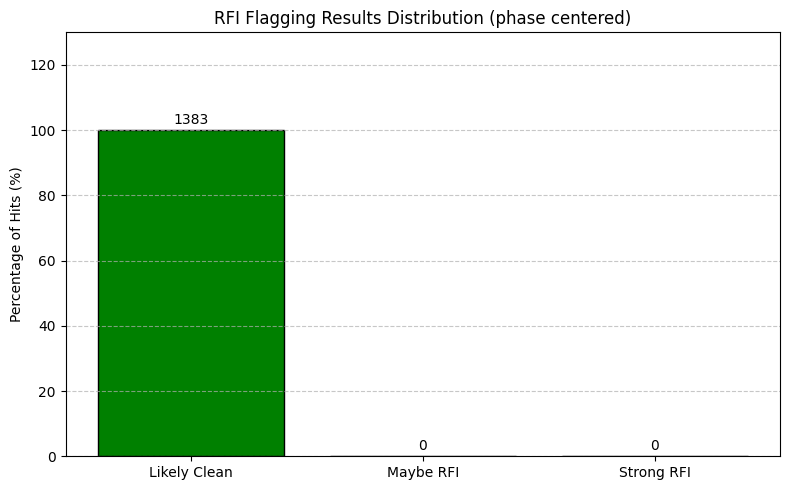

In [58]:

# Counts for each category
counts = {
    "Likely Clean": len(clean_meer_df),
    "Maybe RFI": len(maybe_rfi_meer_df),
    "Strong RFI": len(strong_rfi_meer_df)
}

total = sum(counts.values())

# Calculate percentages
percentages = {k: v / total * 100 for k, v in counts.items()}

# Plot percentages bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(percentages.keys(), percentages.values(), color=['green', 'orange', 'red'], edgecolor='black')
plt.ylabel('Percentage of Hits (%)')
plt.title('RFI Flagging Results Distribution (phase centered)')

# Add count labels above bars
for bar, key in zip(bars, percentages.keys()):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{counts[key]}", ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(percentages.values()) * 1.3)  # add some space above bars
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
#non vlass pickle files 
#clean_df.to_pickle("clean_data/clean_non_vlass.pkl")
#maybe_rfi_df.to_pickle("clean_data/maybe_rfi_non_vlass.pkl")
maybe_rfi_unmatched_df.to_pickle("clean_data/maybe_rfi_unmatched_non_vlass.pkl")
clean_unmatched_df.to_pickle("clean_data/clean_unmatched_non_vlass.pkl")

In [ ]:
#vlass pickle files 
#clean_df.to_pickle("clean_data/clean_vlass.pkl")
#maybe_rfi_df.to_pickle("clean_data/maybe_rfi_vlass.pkl")
#maybe_rfi_unmatched_df.to_pickle("clean_data/maybe_rfi_unmatched_vlass.pkl")
#clean_unmatched_df.to_pickle("clean_data/clean_unmatched_vlass.pkl")

In [72]:
#non vlass
filename_clean = "clean_data/clean_non_vlass.pkl"
filename_maybe = "clean_data/maybe_rfi_non_vlass.pkl"
filename_clean_unmatched = "clean_data/clean_unmatched_non_vlass.pkl"
filename_maybe_unmatched = "clean_data/maybe_rfi_unmatched_non_vlass.pkl"

#vlass 
filename_clean_vlass = "clean_data/clean_vlass.pkl"
filename_maybe_vlass = "clean_data/maybe_rfi_vlass.pkl"
filename_clean_unmatched_vlass = "clean_data/clean_unmatched_vlass.pkl"
filename_maybe_unmatched_vlass = "clean_data/maybe_rfi_unmatched_vlass.pkl"

def append_to_pickle(filename, data):
    if os.path.exists(filename):
        existing_df = pd.read_pickle(filename)
        combined_df = pd.concat([existing_df, data], ignore_index=True)
    else:
        combined_df = data
    combined_df.to_pickle(filename)

#append_to_pickle(filename_clean, clean_df)
#append_to_pickle(filename_maybe, maybe_rfi_df)

#append_to_pickle(filename_clean_unmatched, clean_unmatched_df)
#append_to_pickle(filename_maybe_unmatched, maybe_rfi_unmatched_df)

#append_to_pickle(filename_clean_vlass, clean_df)
#append_to_pickle(filename_maybe_vlass, maybe_rfi_df)

append_to_pickle(filename_clean_unmatched_vlass, clean_unmatched_df)
append_to_pickle(filename_maybe_unmatched_vlass, maybe_rfi_unmatched_df)